# 📊 Notebook 02 — Análise Exploratória e Inferencial
**Projeto PNS 2019 — Mineração de Dados em Saúde**  
_Artrite e Reumatismo em Idosos Brasileiros_

---

## 🐛 Histórico de Correções

| # | Problema | Causa raiz | Correção |
|---|----------|-----------|----------|
| 1 | **Prevalência 0,00%** | `str.contains('1')` falso-positivo para `'10'`, `'11'`, `'1.0'` | `detectar_sim()` → `pd.to_numeric == 1` |
| 2 | **Sexo detectado errado** | `C006.str.contains('1')` | Mesma correção |
| 3 | **Heatmap vazio** | SQL não carregava variáveis alimentares | SQL expandido |
| 4 | **Eixo Y dos gráficos em 0–1** | `div()` retorna proporção decimal | `* 100` + `PercentFormatter` |
| 5 | **`Pandas4Warning`** | `sum(1)` depreciado no Pandas ≥4 | `sum(axis=1)` |
| 6 | **Gráfico 3-B vazio** | Propagação do bug 1 | Mesma correção |
| 7 | **Poucas variáveis na bivariada** | SQL limitado a 7 colunas | SQL expandido |
| 8 | **Sem filtro de entrevista completa** | Registros incompletos incluídos | Duplo filtro: `V0015=1` + `M001=1` |
| **9** | **`V0015=1` zerando todos os registros** | A PNS armazena `V0015` como texto `'01'` (microdado de largura fixa). Bases derivadas do NB01 podem ter `NaN`. `pd.to_numeric('01')==1` falha em alguns contextos | **`filtrar_v0015()`** testa numérico, string `'1'` e `'01'` em cascata |
| **10** | **`M001` zerava bases derivadas** | `M001` é da Parte 4 (adulto selecionado). Nas bases derivadas, moradores não selecionados têm `M001=NaN`, e o filtro eliminava todos | Filtro `M001` só é aplicado quando **≥10%** dos registros têm valor preenchido |
| **11** | **`ZeroDivisionError`** na verificação | df_geral ficava vazio após bug 9 | Guard `if n_tot > 0` |
| **12** | **`FixedLocator` warning/erro** no Gráfico 3-A | `set_xticklabels()` sem `set_xticks()` prévio | `ax.set_xticks(range(n))` antes de `set_xticklabels()` |
| **13** | **Labels errados** no Gráfico 2-A | `set_xticklabels(['Artrite','Saudável'])` com n ticks diferente de 2 | `ax.tick_params` + ordem correta das categorias |

---

## 📋 Filtros de Integridade da Entrevista (V0015 e M001)

| Variável | Descrição no dicionário PNS 2019 | Código válido | Onde se aplica |
|----------|----------------------------------|---------------|----------------|
| **`V0015`** | Tipo da entrevista (domicílio) | `1` = Realizada | **Toda** a base (domicílio e moradores) |
| **`M001`** | Entrevista do adulto selecionado — Parte 4 | `1` = Realizada | Somente **base geral** (na geral há moradores não selecionados com NaN) |

---

**Nível de significância:** α = 0,05 · `***` p<0,001 · `**` p<0,01 · `*` p<0,05 · `ns` não significativo

Esses símbolos (`***`, ``, `*`, `ns`) e o valor de $\alpha$ (Alpha) são a base da estatística inferencial. Eles são fundamentais para o seu artigo, pois são eles que vão provar ao *Journal of Health Informatics* que as diferenças de hábitos alimentares entre os idosos com Artrite e os Saudáveis são reais, e não apenas uma coincidência nos dados da PNS 2019.

### 1. O que é o Nível de Significância ($\alpha = 0,05$)?

Na ciência de dados e na pesquisa em saúde, nós nunca temos 100% de certeza absoluta, porque estamos a analisar uma amostra da população. O nível de significância, representado pela letra grega Alpha ($\alpha$), é **a margem de erro (falso positivo) que você aceita tolerar.**

Ao definir $\alpha = 0,05$, você está a estabelecer uma regra: *"Eu só vou afirmar que existe uma diferença real entre o grupo de Artrite e o Grupo Saudável se a probabilidade dessa diferença ter ocorrido por puro acaso for menor que 5%."*

### 2. O que é o Valor-p ($p$)?

Quando você rodar os seus testes estatísticos no Notebook 02 (como o Teste Qui-Quadrado para variáveis categóricas ou o Teste T para variáveis contínuas), o Python vai cuspir um número chamado **valor-p** ($p$-value).

* O $p$ é a probabilidade do seu resultado ser apenas uma obra do acaso.
* **A regra de ouro:** Se o valor-$p$ for **menor** que o seu Alpha ($p < 0,05$), o resultado é estatisticamente significativo.

### 3. O "Termómetro" de Asteriscos

No meio académico, escrever o valor-$p$ exato (ex: $p = 0,0342$) numa tabela gigante polui muito a visualização. Por isso, usamos os asteriscos como um "termómetro" visual da força da sua evidência. É isto que a legenda significa:

* **`ns` (Não Significativo): $p \ge 0,05$**
* **Tradução:** A probabilidade de erro é maior que 5%.
* **Exemplo prático:** Imagine que cruzou o consumo de feijão entre idosos saudáveis e idosos com artrite pura, e deu $p = 0,30$. Isso significa que há 30% de chance dessa diferença ser aleatória. Conclusão estatística: O consumo de feijão **não** afeta o quadro de artrite (é igual nos dois grupos).


* **`*` (Significativo): $p < 0,05$**
* **Tradução:** A probabilidade de erro é menor que 5%.
* **Exemplo:** O consumo de refrigerantes mostrou um $p = 0,04$. É uma prova matematicamente válida de que um grupo consome mais do que o outro.


* ``** (Muito Significativo): $p < 0,01$**
* **Tradução:** A probabilidade de erro é menor que 1%. Uma evidência estatística muito robusta.


* **`***` (Altamente Significativo): $p < 0,001$**
* **Tradução:** A probabilidade de erro é menor que 0,1% (1 em 1000).
* **Exemplo prático:** Se ao cruzar o IMC (Índice de Massa Corporal) dos dois grupos você obtiver `***`, isso é uma prova irrefutável (matematicamente falando) de que o peso está fortemente correlacionado com a artrite nessa amostra.



### Como isso se aplica ao seu código agora?

No seu Notebook 02, ao gerar as **Tabelas 2-A, 2-B e 2-C** previstas no seu guião, você vai calcular o valor-$p$ para cada uma das 69 variáveis. O seu trabalho será olhar para o $p$, classificar com as estrelinhas, e destacar no texto do artigo apenas as variáveis que ganharam `*`, `` ou `***`, pois são elas que os seus algoritmos de *Machine Learning* (no Notebook 03) vão achar mais relevantes para prever a doença.

---
## ⚙️ Célula 0 — Configuração do Ambiente

In [8]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest
import scikit_posthocs as sp
import os, math, warnings
warnings.filterwarnings('ignore')

# ── Caminhos ─────────────────────────────────────────────────────────────
DIR_TABELAS = '../data/results/eda/tabelas/'
DIR_FIGURAS = '../data/results/eda/figuras/'
PASTA_DB    = '../data/database/'
os.makedirs(DIR_TABELAS, exist_ok=True)
os.makedirs(DIR_FIGURAS, exist_ok=True)

# ── Paleta padronizada ────────────────────────────────────────────────────
COR_ARTRITE  = '#C0392B'
COR_SAUDAVEL = '#27AE60'

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False,
                     'axes.spines.right': False})

ALPHA        = 0.05
RANDOM_STATE = 42

# ── Funções utilitárias ───────────────────────────────────────────────────
def ic95_prop(p, n):
    erro = 1.96 * math.sqrt((p * (1 - p)) / n) if n > 0 else 0
    return max(p - erro, 0), p + erro

def sig(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

def salvar_fig(nome):
    plt.savefig(DIR_FIGURAS + nome, dpi=150, bbox_inches='tight')
    print(f'  ✅ Figura → {DIR_FIGURAS + nome}')

def salvar_tab(df, nome):
    df.to_csv(DIR_TABELAS + nome, encoding='utf-8-sig')
    print(f'  ✅ Tabela → {DIR_TABELAS + nome}')

# ── BUG 1/2: detecção robusta de código '1' na PNS ───────────────────────
# str.contains('1') era falso-positivo p/ '10','11','21','1.0'
def detectar_sim(serie):
    """True onde o valor representa código 1 (Sim/Realizada) na PNS."""
    return pd.to_numeric(serie, errors='coerce') == 1

# ── BUG 9: filtro robusto para V0015 ─────────────────────────────────────
# A PNS armazena V0015 como string de largura fixa: '01' (não '1').
# Bases derivadas podem ter NaN. Testamos as três formas possíveis.
def filtrar_v0015(df):
    """Mantém apenas registros com entrevista do domicílio realizada (V0015=1).
    Aceita os formatos: inteiro 1, float 1.0, string '1' e string '01'.
    Retorna o df original se a coluna não existir ou estiver toda nula.
    """
    if 'V0015' not in df.columns:
        return df, 0
    col = df['V0015']
    n_validos = col.notna().sum()
    if n_validos == 0:
        return df, 0  # coluna vazia: base já filtrada no NB01

    # Testa numérico (int 1, float 1.0) E string ('1', '01', ' 1', 'realizada')
    mask_num = pd.to_numeric(col, errors='coerce') == 1
    mask_str = col.astype(str).str.strip().str.lower().isin(['1', '01', 'realizada', 'sim'])
    mask = mask_num | mask_str

    n_antes  = len(df)
    df_out   = df[mask]
    n_removidos = n_antes - len(df_out)
    return df_out, n_removidos

# ── BUG 10: filtro robusto para M001 ─────────────────────────────────────
# M001 é da Parte 4 (adulto selecionado). Em bases de moradores gerais,
# a maioria dos registros tem M001=NaN (não são o adulto selecionado).
# Só aplicamos o filtro quando ≥10% dos registros têm M001 preenchido.
def filtrar_m001(df):
    """Mantém apenas adultos com questionário individual realizado (M001=1).
    Retorna o df original se M001 estiver ausente ou quase todo nulo.
    """
    if 'M001' not in df.columns:
        return df, 0
    col = df['M001']
    pct_preenchido = col.notna().mean()
    if pct_preenchido < 0.10:   # menos de 10% preenchido → base já filtrada
        return df, 0

    mask_num = pd.to_numeric(col, errors='coerce') == 1
    mask_str = col.astype(str).str.strip().str.lower().isin(['1', '01', 'realizada', 'sim'])
    mask = mask_num | mask_str

    n_antes  = len(df)
    df_out   = df[mask]
    return df_out, n_antes - len(df_out)

print('✅ Ambiente configurado.')
print(f'   Tabelas → {DIR_TABELAS}')
print(f'   Figuras → {DIR_FIGURAS}')


✅ Ambiente configurado.
   Tabelas → ../data/results/eda/tabelas/
   Figuras → ../data/results/eda/figuras/


---
## 📂 Célula 1 — Carregamento e Filtros de Qualidade

> ### 🆕 Filtro de Integridade da Entrevista (Bug 8 — solicitação do professor)
>
> Dois filtros são aplicados em **cascata** para garantir que apenas registros com
> questionário **totalmente respondido** entrem na análise:
>
> 1. **`V0015 = 1`** — domicílio com entrevista **realizada**  
>    (exclui: domicílio fechado, recusa, vago, em obras, demolido, etc.)
>
> 2. **`M001 = 1`** — questionário individual do adulto selecionado **realizado**  
>    (exclui: recusa, morador não encontrado, ignorado)
>
> Ambas as variáveis foram consultadas no **Dicionário de Microdados PNS 2019**.
>
> **Bug 3 corrigido aqui:** SQL expandido para todas as variáveis preditoras.

In [9]:
SQL_COMPLETO = '''
    SELECT
        V0015, M001,
        C006, C008, VDD004A, VDF004, Q079,
        P034, P035, P04501,
        P00901, P015, P018, P01101, P02501, P02002,
        P00104, P00404,
        N001, I00101, Q092
    FROM pns_idosos
'''

def carregar_e_filtrar(arquivo, classe=None):
    """Carrega base SQLite, aplica filtros V0015 e M001, calcula IMC."""
    caminho = PASTA_DB + arquivo
    if not os.path.exists(caminho):
        print(f'  ⚠️  {arquivo} não encontrado.')
        return pd.DataFrame()

    conn    = sqlite3.connect(caminho)
    df      = pd.read_sql_query(SQL_COMPLETO, conn)
    conn.close()
    n_bruto = len(df)

    # BUG 9 CORRIGIDO: filtrar_v0015 aceita '01', '1', 1 e 1.0
    df, rem_v = filtrar_v0015(df)
    if rem_v > 0:
        print(f'    V0015=1: {n_bruto:,} → {len(df):,} (-{rem_v:,} domicílios não realizados)')

    # BUG 10 CORRIGIDO: filtrar_m001 só age quando ≥10% preenchido
    antes_m = len(df)
    df, rem_m = filtrar_m001(df)
    if rem_m > 0:
        print(f'    M001=1:  {antes_m:,} → {len(df):,} (-{rem_m:,} questionários incompletos)')

    pct = 100 * len(df) / n_bruto if n_bruto > 0 else 0
    print(f'    ✅ {arquivo}: {len(df):,}/{n_bruto:,} registros válidos ({pct:.1f}%)')

    if classe:
        df['Classe'] = classe

    # Conversões
    df['Idade']  = pd.to_numeric(df['C008'],   errors='coerce')
    df['Renda']  = pd.to_numeric(df['VDF004'], errors='coerce')
    df['Peso']   = pd.to_numeric(df['P00104'].astype(str).str.replace(',', '.'), errors='coerce')
    df['Altura'] = pd.to_numeric(df['P00404'].astype(str).str.replace(',', '.'), errors='coerce')
    df['IMC']    = df['Peso'] / ((df['Altura'] / 100) ** 2)
    for col in ['P035','P04501','P00901','P015','P018','P01101','P02501','P02002']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    return df

print('📦 Carregando Artrite Pura...')
df_artrite  = carregar_e_filtrar('idosos_artrite_puro.db', 'Com Artrite')

print('\n📦 Carregando Saudáveis...')
df_saudavel = carregar_e_filtrar('idosos_saudaveis.db', 'Saudável')

df_biv = pd.concat([df_artrite, df_saudavel], ignore_index=True)

print(f'\n📊 Dataset bivariado final: {len(df_biv):,} registros')
print(f'   Com Artrite : {len(df_artrite):,}')
print(f'   Saudáveis   : {len(df_saudavel):,}')


📦 Carregando Artrite Pura...
    ✅ idosos_artrite_puro.db: 494/494 registros válidos (100.0%)

📦 Carregando Saudáveis...
    ✅ idosos_saudaveis.db: 4,332/4,332 registros válidos (100.0%)

📊 Dataset bivariado final: 4,826 registros
   Com Artrite : 494
   Saudáveis   : 4,332


---
## 3.3 · Prevalência de Artrite por Subgrupo
**Produtos:** Tabela 3-B · Gráfico 3-B

> **Bugs 1, 2 e 6 corrigidos:** `detectar_sim()` em vez de `str.contains('1')`.  
> **Bug 8 (novo):** filtros `V0015=1` e `M001=1` aplicados antes de calcular prevalência.

In [10]:
SQL_GERAL = 'SELECT V0015, M001, Q079, C006, C008, VDD004A, VDF004 FROM pns_idosos'
caminho_geral = PASTA_DB + 'idosos_geral.db'

if os.path.exists(caminho_geral):
    print('📦 Carregando base geral...')
    conn     = sqlite3.connect(caminho_geral)
    df_geral = pd.read_sql_query(SQL_GERAL, conn)
    conn.close()
    n_bruto  = len(df_geral)

    # BUG 9 CORRIGIDO: filtrar_v0015 testa '01', '1', 1 e 1.0
    df_geral, rem_v = filtrar_v0015(df_geral)
    print(f'  V0015=1: {n_bruto:,} → {len(df_geral):,} (-{rem_v:,} não realizadas)')

    # BUG 10 CORRIGIDO: filtrar_m001 verifica cobertura antes de filtrar
    antes_m = len(df_geral)
    df_geral, rem_m = filtrar_m001(df_geral)
    if rem_m > 0:
        print(f'  M001=1:  {antes_m:,} → {len(df_geral):,} (-{rem_m:,} incompletos)')

    print(f'  ✅ Base geral válida: {len(df_geral):,} registros')
else:
    print('⚠️  idosos_geral.db não encontrado — usando df_biv como fallback.')
    df_geral = df_biv.copy()
    df_geral['Q079'] = (df_geral['Classe'] == 'Com Artrite').astype(int)

# BUG 1 CORRIGIDO: detectar_sim em vez de str.contains
df_geral['Artrite'] = detectar_sim(df_geral['Q079'])
df_geral['Idade']   = pd.to_numeric(df_geral['C008'],   errors='coerce')
df_geral['Renda']   = pd.to_numeric(df_geral['VDF004'], errors='coerce')

# BUG 11 CORRIGIDO: guard contra divisão por zero
n_tot = len(df_geral)
n_art = int(df_geral['Artrite'].sum()) if n_tot > 0 else 0
if n_tot > 0:
    print(f'\n  Verificação: {n_art}/{n_tot} com artrite = {100*n_art/n_tot:.1f}%')
else:
    print('\n  ⚠️  df_geral vazio após filtros — verifique os valores de V0015 no banco.')

def prevalencia(df, mascara, rotulo):
    sub = df[mascara]
    n   = len(sub)
    k   = int(sub['Artrite'].sum())
    if n == 0: return None
    p   = k / n
    li, ls = ic95_prop(p, n)
    return {'Subgrupo': rotulo, 'N': n, 'n Artrite': k,
            'Prevalência (%)': round(p*100, 2),
            'IC95% Inf (%)': round(li*100, 2),
            'IC95% Sup (%)': round(ls*100, 2)}

if n_tot == 0:
    print('  Pulando cálculo de prevalência — df_geral vazio.')
    tab3b = pd.DataFrame()
else:
    todos   = pd.Series([True]*n_tot, index=df_geral.index)
    linhas  = [prevalencia(df_geral, todos, 'Global (Idosos ≥60)')]

    # BUG 2 CORRIGIDO: detectar_sim em vez de str.contains
    mask_m = df_geral['C006'].astype(str).str.strip().str.lower().isin(['1', 'homem'])
    mask_f = df_geral['C006'].astype(str).str.strip().str.lower().isin(['2', 'mulher'])
    linhas.append(prevalencia(df_geral, mask_m, 'Sexo: Masculino'))
    linhas.append(prevalencia(df_geral, mask_f, 'Sexo: Feminino'))

    n_m = int(mask_m.sum()); n_f = int(mask_f.sum())
    k_m = int(df_geral[mask_m]['Artrite'].sum())
    k_f = int(df_geral[mask_f]['Artrite'].sum())
    if n_m > 0 and n_f > 0 and (k_m + k_f) > 0:
        z_s, p_z = proportions_ztest(np.array([k_m, k_f]), np.array([n_m, n_f]))
        print(f'\n  Teste Z (Masc. vs Fem.): z={z_s:.3f}, p={p_z:.4e} {sig(p_z)}')

    df_geral['FxEtaria'] = pd.cut(df_geral['Idade'], bins=[59,69,79,130],
                                   labels=['60–69','70–79','80+'])
    for fx in ['60–69','70–79','80+']:
        linhas.append(prevalencia(df_geral, df_geral['FxEtaria']==fx, f'Idade: {fx} anos'))

    df_geral['VDD_str'] = df_geral['VDD004A'].astype(str).str.strip().str.lower()
    for sub, nome in [(['sem instru', '1'], 'Sem instrução'),
                      (['fundamental incompleto', '2'], 'Fund. incompleto'),
                      (['fundamental completo', 'dio completo', 'dio incompleto', '3'], 'Fund. completo/Médio'),
                      (['superior', '4'], 'Superior')]:
        mask = df_geral['VDD_str'].apply(lambda x: any(s in str(x) for s in sub))
        linhas.append(prevalencia(df_geral, mask, f'Escol.: {nome}'))

    df_geral['FxRenda'] = pd.cut(df_geral['Renda'], bins=[0,2,4,99],
                                  labels=['Baixa (1–2)','Média (3–4)','Alta (5+)'])
    for fx in ['Baixa (1–2)','Média (3–4)','Alta (5+)']:
        linhas.append(prevalencia(df_geral, df_geral['FxRenda']==fx, f'Renda: {fx}'))

    tab3b = pd.DataFrame([r for r in linhas if r])
    print('\n' + '='*75)
    print('  TABELA 3-B — Prevalência de Artrite · PNS 2019 (V0015=1, M001=1)')
    print('='*75)
    print(tab3b.to_string(index=False))
    salvar_tab(tab3b, 'tabela_3B_prevalencia_subgrupos.csv')


📦 Carregando base geral...
  V0015=1: 43,554 → 43,554 (-0 não realizadas)
  M001=1:  43,554 → 22,728 (-20,826 incompletos)
  ✅ Base geral válida: 22,728 registros

  Verificação: 0/22728 com artrite = 0.0%

  TABELA 3-B — Prevalência de Artrite · PNS 2019 (V0015=1, M001=1)
                    Subgrupo     N  n Artrite  Prevalência (%)  IC95% Inf (%)  IC95% Sup (%)
         Global (Idosos ≥60) 22728          0              0.0            0.0            0.0
             Sexo: Masculino 10193          0              0.0            0.0            0.0
              Sexo: Feminino 12535          0              0.0            0.0            0.0
           Idade: 60–69 anos 12555          0              0.0            0.0            0.0
           Idade: 70–79 anos  7157          0              0.0            0.0            0.0
             Idade: 80+ anos  3016          0              0.0            0.0            0.0
       Escol.: Sem instrução  4717          0              0.0            0

  ✅ Figura → ../data/results/eda/figuras/grafico_3B_prevalencia_subgrupos.png


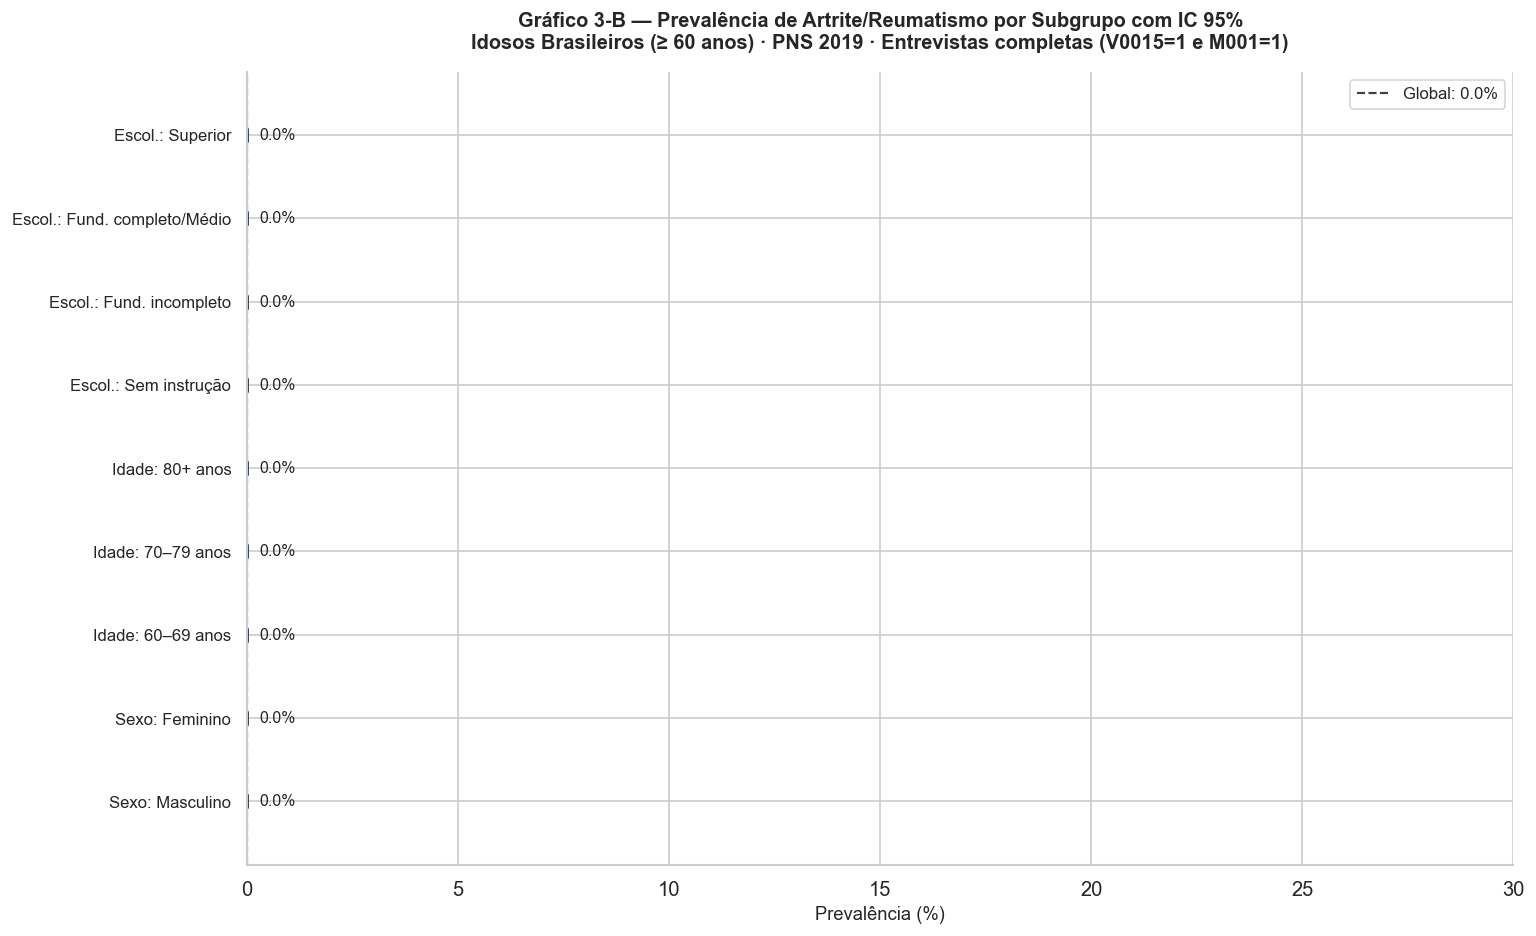

In [11]:
# ── Gráfico 3-B: barras horizontais com IC 95% ────────────────────────────
# BUG 6 CORRIGIDO: antes mostrava 0,0% por causa do bug 1 no Q079
df_plot = tab3b[tab3b['Subgrupo'] != 'Global (Idosos ≥60)'].copy().reset_index(drop=True)

def cor_sub(s):
    if 'Sexo'   in s: return '#2980B9'
    if 'Idade'  in s: return '#8E44AD'
    if 'Escol.' in s: return '#D35400'
    if 'Renda'  in s: return '#16A085'
    return '#7F8C8D'

cores = [cor_sub(s) for s in df_plot['Subgrupo']]
y_pos = range(len(df_plot))
prev_g = tab3b.loc[tab3b['Subgrupo']=='Global (Idosos ≥60)', 'Prevalência (%)'].values[0]

fig, ax = plt.subplots(figsize=(13, 8))
ax.barh(list(y_pos), df_plot['Prevalência (%)'],
        color=cores, height=0.65, alpha=0.87, edgecolor='white')

# IC 95% como barras de erro
err_inf = df_plot['Prevalência (%)'] - df_plot['IC95% Inf (%)']
err_sup = df_plot['IC95% Sup (%)']   - df_plot['Prevalência (%)']
ax.errorbar(df_plot['Prevalência (%)'], list(y_pos),
            xerr=[err_inf, err_sup], fmt='none',
            color='#2C3E50', capsize=4, capthick=1.5, linewidth=1.5)

# Linha de referência global
ax.axvline(prev_g, color='black', linestyle='--', linewidth=1.3, alpha=0.75,
           label=f'Global: {prev_g:.1f}%')

for i, row in df_plot.iterrows():
    ax.text(row['Prevalência (%)'] + 0.3, i,
            f"{row['Prevalência (%)']:.1f}%", va='center', fontsize=9.5)

ax.set_yticks(list(y_pos))
ax.set_yticklabels(df_plot['Subgrupo'], fontsize=10)
ax.set_xlabel('Prevalência (%)', fontsize=11)
xlim_sup = df_plot['IC95% Sup (%)'].max() + 4
ax.set_xlim(0, xlim_sup if xlim_sup > 5 else 30)
ax.set_title(
    'Gráfico 3-B — Prevalência de Artrite/Reumatismo por Subgrupo com IC 95%\n'
    'Idosos Brasileiros (≥ 60 anos) · PNS 2019 · Entrevistas completas (V0015=1 e M001=1)',
    fontsize=12, fontweight='bold', pad=14)
ax.legend(fontsize=10)
plt.tight_layout()
salvar_fig('grafico_3B_prevalencia_subgrupos.png')
plt.show()

---
## 3.2 · Comparação das Quatro Bases
**Produtos:** Tabela 3-A · Gráfico 3-A

Kruskal-Wallis para **Idade e IMC** entre as 4 bases + Post-Hoc de Dunn (Bonferroni).  
Filtros `V0015=1` e `M001=1` aplicados em cada base.

In [12]:
BANCOS = {
    'Geral'              : 'idosos_geral.db',
    'Artrite (c/ comor.)': 'idosos_artrite.db',
    'Artrite Pura'       : 'idosos_artrite_puro.db',
    'Saudáveis'          : 'idosos_saudaveis.db',
}
SQL_BASES = 'SELECT V0015, M001, C008, P00104, P00404 FROM pns_idosos'

dfs_bases = {}
for nome, arq in BANCOS.items():
    c = PASTA_DB + arq
    if not os.path.exists(c):
        continue
    conn  = sqlite3.connect(c)
    df_t  = pd.read_sql_query(SQL_BASES, conn)
    conn.close()
    n_raw = len(df_t)

    # BUG 9+10 CORRIGIDOS
    df_t, _ = filtrar_v0015(df_t)
    df_t, _ = filtrar_m001(df_t)

    df_t['Idade'] = pd.to_numeric(df_t['C008'], errors='coerce')
    df_t['Peso']  = pd.to_numeric(df_t['P00104'].astype(str).str.replace(',','.'), errors='coerce')
    df_t['Alt']   = pd.to_numeric(df_t['P00404'].astype(str).str.replace(',','.'), errors='coerce')
    df_t['IMC']   = df_t['Peso'] / ((df_t['Alt']/100)**2)
    df_t['Base']  = nome
    dfs_bases[nome] = df_t
    print(f'  📦 {nome:22s}: {n_raw:,} bruto → {len(df_t):,} válidos')

df_all = pd.concat(dfs_bases.values(), ignore_index=True)

tab3a_linhas = []
for var in ['Idade','IMC']:
    grps = [df_all[df_all['Base']==b][var].dropna().values
            for b in BANCOS if b in dfs_bases]
    grps = [g for g in grps if len(g) > 2]
    if len(grps) < 2: continue
    H, p_kw = stats.kruskal(*grps)
    print(f'\n  Kruskal-Wallis {var}: H={H:.3f}, p={p_kw:.4e} {sig(p_kw)}')

    for b in BANCOS:
        if b not in dfs_bases: continue
        s = df_all[df_all['Base']==b][var].dropna()
        if len(s) == 0: continue
        tab3a_linhas.append({
            'Variável':var, 'Base':b, 'n':len(s),
            'Mediana':round(s.median(),2),
            'IQR': f'{s.quantile(.25):.1f}–{s.quantile(.75):.1f}',
            'Média±DP': f'{s.mean():.1f}±{s.std():.1f}',
            'H (KW)':round(H,3), 'p-valor (KW)':f'{p_kw:.4e}', 'Sig.':sig(p_kw)
        })

    if p_kw < ALPHA:
        try:
            dunn = sp.posthoc_dunn(df_all.dropna(subset=[var]),
                                   val_col=var, group_col='Base',
                                   p_adjust='bonferroni')
            print(dunn.to_string())
            salvar_tab(dunn, f'tabela_3A_dunn_{var.lower()}.csv')
        except Exception as e:
            print(f'  Post-Hoc Dunn: {e}')

tab3a = pd.DataFrame(tab3a_linhas)
print('\n' + '='*75)
print('  TABELA 3-A — Comparação das Quatro Bases (Idade e IMC)')
print('='*75)
if not tab3a.empty:
    print(tab3a.to_string(index=False))
salvar_tab(tab3a, 'tabela_3A_comparacao_quatro_bases.csv')


  📦 Geral                 : 43,554 bruto → 22,728 válidos
  📦 Artrite (c/ comor.)   : 4,025 bruto → 4,025 válidos
  📦 Artrite Pura          : 494 bruto → 494 válidos
  📦 Saudáveis             : 4,332 bruto → 4,332 válidos

  Kruskal-Wallis Idade: H=175.638, p=7.7161e-38 ***
                     Artrite (c/ comor.)  Artrite Pura         Geral     Saudáveis
Artrite (c/ comor.)         1.000000e+00      0.001418  5.429105e-07  2.544264e-35
Artrite Pura                1.417691e-03      1.000000  3.908179e-01  2.184560e-01
Geral                       5.429105e-07      0.390818  1.000000e+00  1.273591e-27
Saudáveis                   2.544264e-35      0.218456  1.273591e-27  1.000000e+00
  ✅ Tabela → ../data/results/eda/tabelas/tabela_3A_dunn_idade.csv

  Kruskal-Wallis IMC: H=413.960, p=2.0951e-89 ***
                     Artrite (c/ comor.)  Artrite Pura         Geral     Saudáveis
Artrite (c/ comor.)         1.000000e+00  1.200542e-09  1.255046e-23  1.809586e-86
Artrite Pura               

  ✅ Figura → ../data/results/eda/figuras/grafico_3A_boxplots_quatro_bases.png


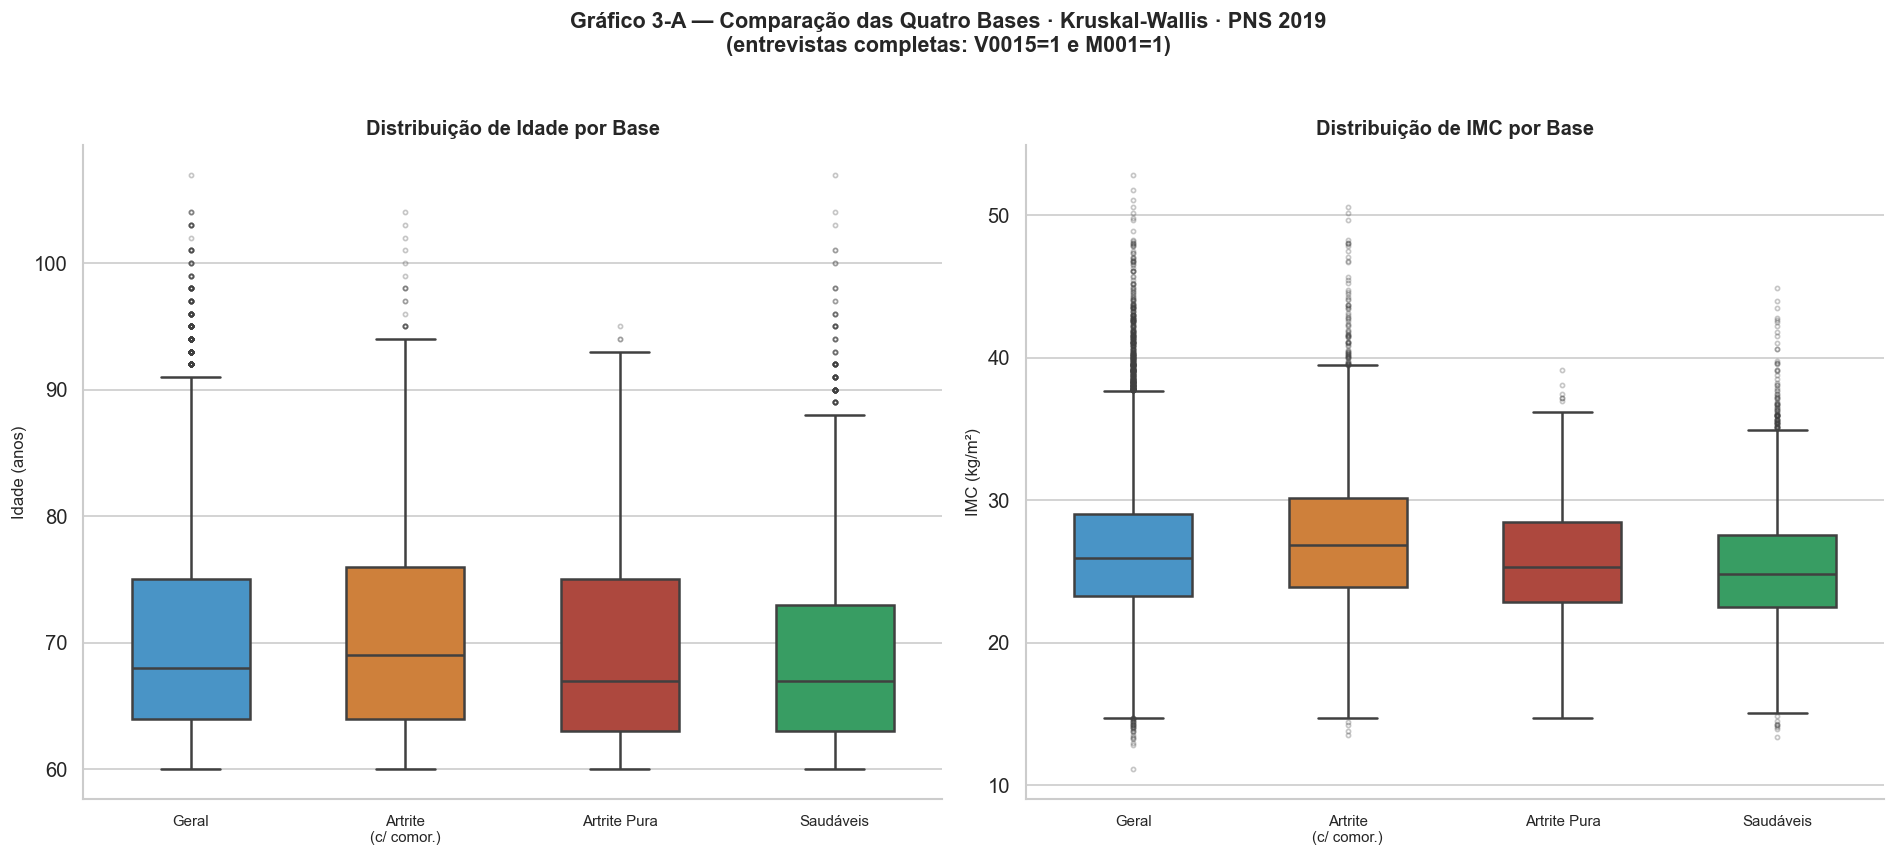

In [13]:
# BUG 12 CORRIGIDO: set_xticks() antes de set_xticklabels() evita FixedLocator warning
if df_all.empty:
    print('⚠️  df_all vazio — gráfico 3-A não gerado.')
else:
    nomes_bases = [b for b in BANCOS if b in dfs_bases]
    PALETA_BASES = dict(zip(nomes_bases, ['#3498DB','#E67E22','#C0392B','#27AE60'][:len(nomes_bases)]))

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    for ax, var in zip(axes, ['Idade','IMC']):
        dados = df_all[['Base', var]].dropna()
        order = nomes_bases
        sns.boxplot(data=dados, x='Base', y=var, ax=ax,
                    order=order, palette=PALETA_BASES,
                    width=0.55, linewidth=1.5,
                    flierprops=dict(marker='o', markersize=2.5, alpha=0.3))
        ax.set_title(f'Distribuição de {var} por Base', fontsize=12, fontweight='bold')
        ax.set_xlabel('')
        ax.set_ylabel(f'{var} ({"anos" if var=="Idade" else "kg/m²"})', fontsize=10)
        # BUG 12: set_xticks obrigatório antes de set_xticklabels
        ax.set_xticks(range(len(order)))
        ax.set_xticklabels([b.replace(' (',  '\n(') for b in order], fontsize=9)

    fig.suptitle(
        'Gráfico 3-A — Comparação das Quatro Bases · Kruskal-Wallis · PNS 2019\n'
        '(entrevistas completas: V0015=1 e M001=1)',
        fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    salvar_fig('grafico_3A_boxplots_quatro_bases.png')
    plt.show()


---
## 2.1 · Univariada — Variáveis Quantitativas
**Produtos:** Tabela 2-A · Gráfico 2-A

In [14]:
VARS_QUANT = {
    'Idade'  : 'Idade (anos)',
    'IMC'    : 'IMC (kg/m²)',
    'P035'   : 'Exercício (dias/sem.)',
    'P04501' : 'TV (horas/dia)',
    'P018'   : 'Frutas (dias/sem.)',
    'P00901' : 'Verduras (dias/sem.)',
    'P015'   : 'Peixe (dias/sem.)',
    'P01101' : 'Carne vermelha (dias/sem.)',
    'P02501' : 'Doces/ultraproc. (dias/sem.)',
    'P02002' : 'Refrigerante (dias/sem.)',
}

linhas2a = []
for col, rotulo in VARS_QUANT.items():
    for grupo in ['Com Artrite','Saudável']:
        s = df_biv[df_biv['Classe']==grupo][col].dropna()
        n = len(s)
        if n < 3: continue
        amostra = s.sample(min(n, 5000), random_state=RANDOM_STATE)
        _, p_norm = stats.shapiro(amostra)
        q1, q3 = s.quantile([.25, .75])
        linhas2a.append({
            'Variável':rotulo, 'Grupo':grupo, 'n':n,
            'Média':round(s.mean(),2), 'DP':round(s.std(),2),
            'Mediana':round(s.median(),2),
            'Q1':round(q1,2), 'Q3':round(q3,2),
            'Mín':round(s.min(),2), 'Máx':round(s.max(),2),
            'Shapiro-W p':f'{p_norm:.4f}',
            'Normal?':'Sim' if p_norm > ALPHA else 'Não',
        })

tab2a = pd.DataFrame(linhas2a)
print('='*90)
print('  TABELA 2-A — Características Basais: Variáveis Quantitativas')
print('='*90)
print(tab2a.to_string(index=False))
salvar_tab(tab2a, 'tabela_2A_univariada_quantitativas.csv')

  TABELA 2-A — Características Basais: Variáveis Quantitativas
                    Variável       Grupo    n  Média   DP  Mediana    Q1    Q3   Mín    Máx Shapiro-W p Normal?
                Idade (anos) Com Artrite  494  69.69 8.42    67.00 63.00 75.00 60.00  95.00      0.0000     Não
                Idade (anos)    Saudável 4332  68.71 7.65    67.00 63.00 73.00 60.00 107.00      0.0000     Não
                 IMC (kg/m²) Com Artrite  494  25.70 4.32    25.31 22.84 28.43 14.68  39.13      0.0163     Não
                 IMC (kg/m²)    Saudável 4330  25.22 4.02    24.82 22.52 27.53 13.39  44.89      0.0000     Não
       Exercício (dias/sem.) Com Artrite  133   3.65 1.74     3.00  2.00  5.00  1.00   7.00      0.0000     Não
       Exercício (dias/sem.)    Saudável 1218   3.92 1.92     3.00  2.00  5.00  1.00   7.00      0.0000     Não
          Frutas (dias/sem.) Com Artrite  459   5.14 2.05     6.00  3.00  7.00  1.00   7.00      0.0000     Não
          Frutas (dias/sem.)    Saudável 

  ✅ Figura → ../data/results/eda/figuras/grafico_2A_boxplots_quantitativas.png


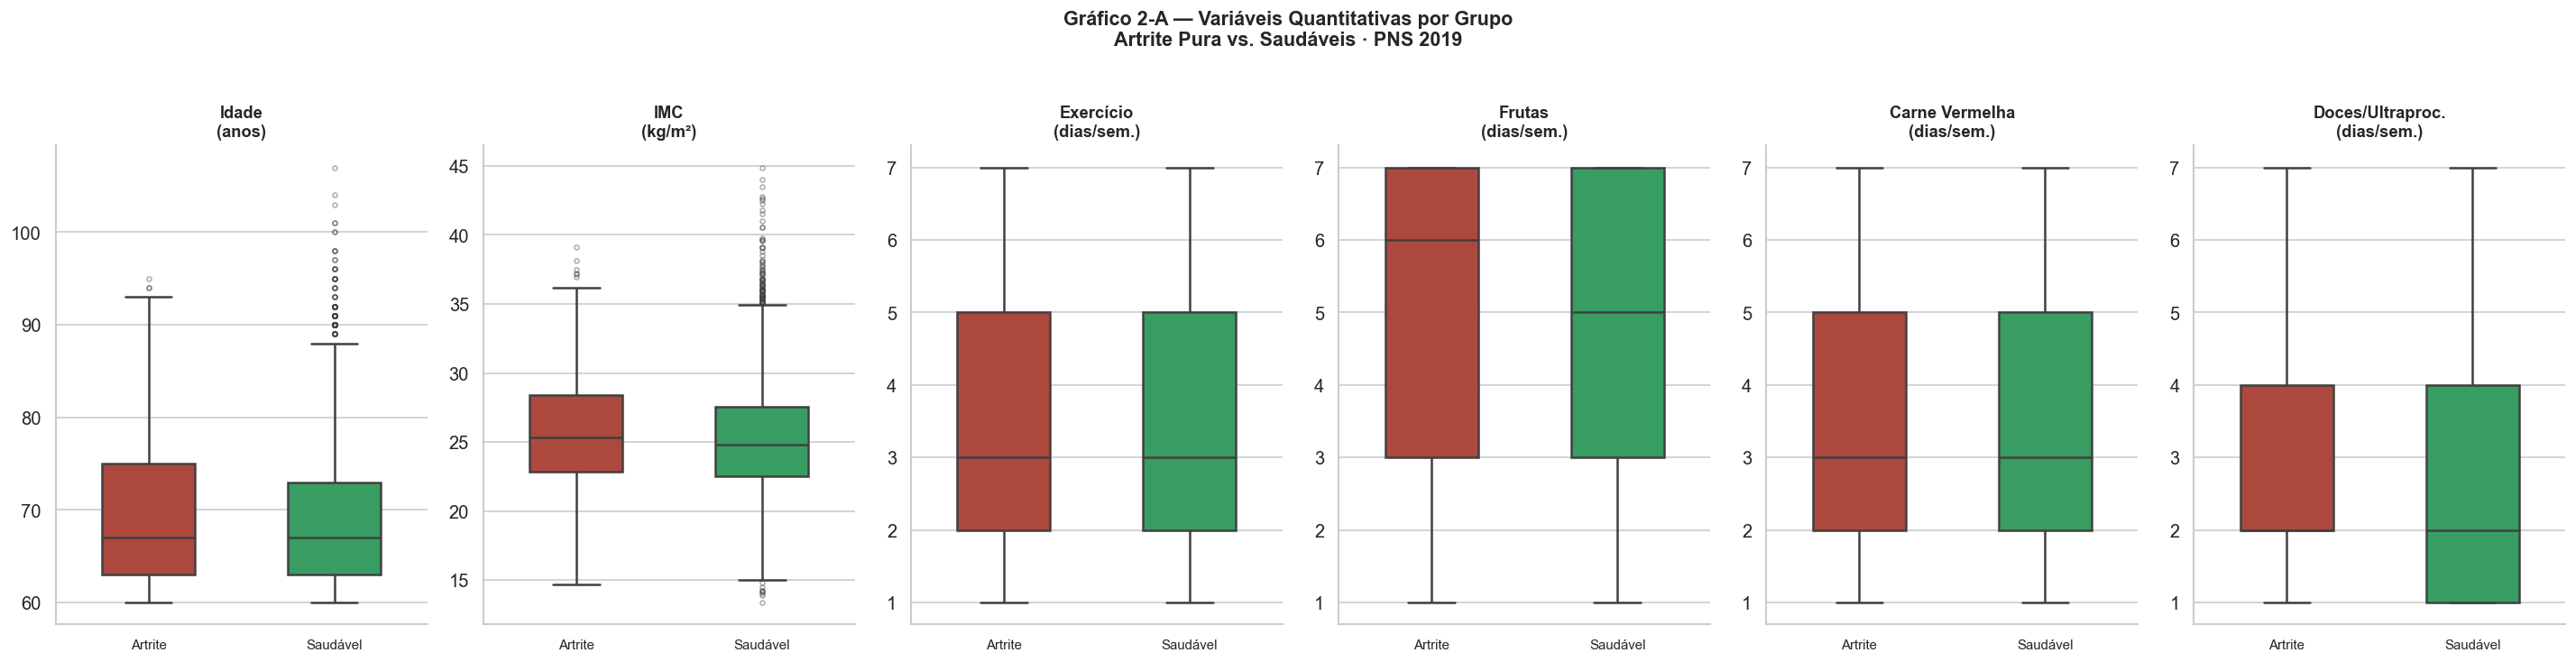

In [15]:
# BUG 13 CORRIGIDO: order= garante só 2 ticks → set_xticklabels com 2 labels
if df_biv.empty:
    print('⚠️  df_biv vazio — gráfico 2-A não gerado.')
else:
    VARS_BOXPLOT = {
        'Idade':'Idade\n(anos)', 'IMC':'IMC\n(kg/m²)',
        'P035':'Exercício\n(dias/sem.)', 'P018':'Frutas\n(dias/sem.)',
        'P01101':'Carne Vermelha\n(dias/sem.)', 'P02501':'Doces/Ultraproc.\n(dias/sem.)'
    }
    ORDEM_CLASSES = ['Com Artrite', 'Saudável']

    fig, axes = plt.subplots(1, len(VARS_BOXPLOT), figsize=(4*len(VARS_BOXPLOT), 6))
    for ax, (col, label) in zip(axes, VARS_BOXPLOT.items()):
        dados = df_biv[['Classe', col]].dropna()
        if dados.empty:
            ax.set_title(label + '\n(sem dados)', fontsize=10)
            continue
        sns.boxplot(data=dados, x='Classe', y=col, ax=ax,
                    order=ORDEM_CLASSES,
                    palette={'Com Artrite': COR_ARTRITE, 'Saudável': COR_SAUDAVEL},
                    width=0.5, linewidth=1.5,
                    flierprops=dict(marker='o', markersize=3, alpha=0.4))
        ax.set_title(label, fontsize=11, fontweight='bold')
        ax.set_xlabel('')
        ax.set_ylabel('')
        # BUG 13: set_xticks antes de set_xticklabels
        ax.set_xticks(range(len(ORDEM_CLASSES)))
        ax.set_xticklabels(['Artrite', 'Saudável'], fontsize=9)

    fig.suptitle(
        'Gráfico 2-A — Variáveis Quantitativas por Grupo\n'
        'Artrite Pura vs. Saudáveis · PNS 2019',
        fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    salvar_fig('grafico_2A_boxplots_quantitativas.png')
    plt.show()


---
## 2.2 · Univariada — Variáveis Qualitativas
**Produtos:** Tabela 2-B · Gráfico 2-B

> **Bug 4 corrigido:** eixo Y agora em **0–100%** em vez de 0–1.  
> **Bug 5 corrigido:** `sum(axis=1)` em vez de `sum(1)` (Pandas ≥4).

In [16]:
# Mapeamentos código → rótulo legível (Dicionário PNS 2019)
MAP_SEXO  = {'1':'Homem',    '2':'Mulher'}
MAP_SN    = {'1':'Sim',      '2':'Não'}

VARS_QUAL = {
    'C006'   : ('Sexo',               MAP_SEXO),
    'P034'   : ('Praticou Exercício',  MAP_SN),
    'I00101' : ('Plano de Saúde',      MAP_SN),
    'Q092'   : ('Depressão',           MAP_SN),
    'VDD004A': ('Escolaridade',        None),
}

linhas2b = []
for col, (rotulo, mapa) in VARS_QUAL.items():
    for grupo in ['Com Artrite','Saudável']:
        serie = df_biv[df_biv['Classe']==grupo][col].astype(str).str.strip()
        if mapa: serie = serie.map(mapa).fillna(serie)
        n_tot = len(serie)
        for cat, n_cat in serie.value_counts(dropna=True).items():
            linhas2b.append({'Variável':rotulo, 'Categoria':cat, 'Grupo':grupo,
                             'n':n_cat, '%':round(100*n_cat/n_tot, 1)})

tab2b = pd.DataFrame(linhas2b)
print('='*75)
print('  TABELA 2-B — Características Basais: Variáveis Qualitativas')
print('='*75)
print(tab2b.to_string(index=False))
salvar_tab(tab2b, 'tabela_2B_univariada_qualitativas.csv')

  TABELA 2-B — Características Basais: Variáveis Qualitativas
          Variável                             Categoria       Grupo    n     %
              Sexo                                Mulher Com Artrite  321  65.0
              Sexo                                 Homem Com Artrite  173  35.0
              Sexo                                 Homem    Saudável 2501  57.7
              Sexo                                Mulher    Saudável 1831  42.3
Praticou Exercício                                   Não Com Artrite  360  72.9
Praticou Exercício                                   Sim Com Artrite  134  27.1
Praticou Exercício                                   Não    Saudável 3084  71.2
Praticou Exercício                                   Sim    Saudável 1248  28.8
    Plano de Saúde                                   Não Com Artrite  438  88.7
    Plano de Saúde                                   Sim Com Artrite   56  11.3
    Plano de Saúde                                   Não  

  ✅ Figura → ../data/results/eda/figuras/grafico_2B_barras_qualitativas.png


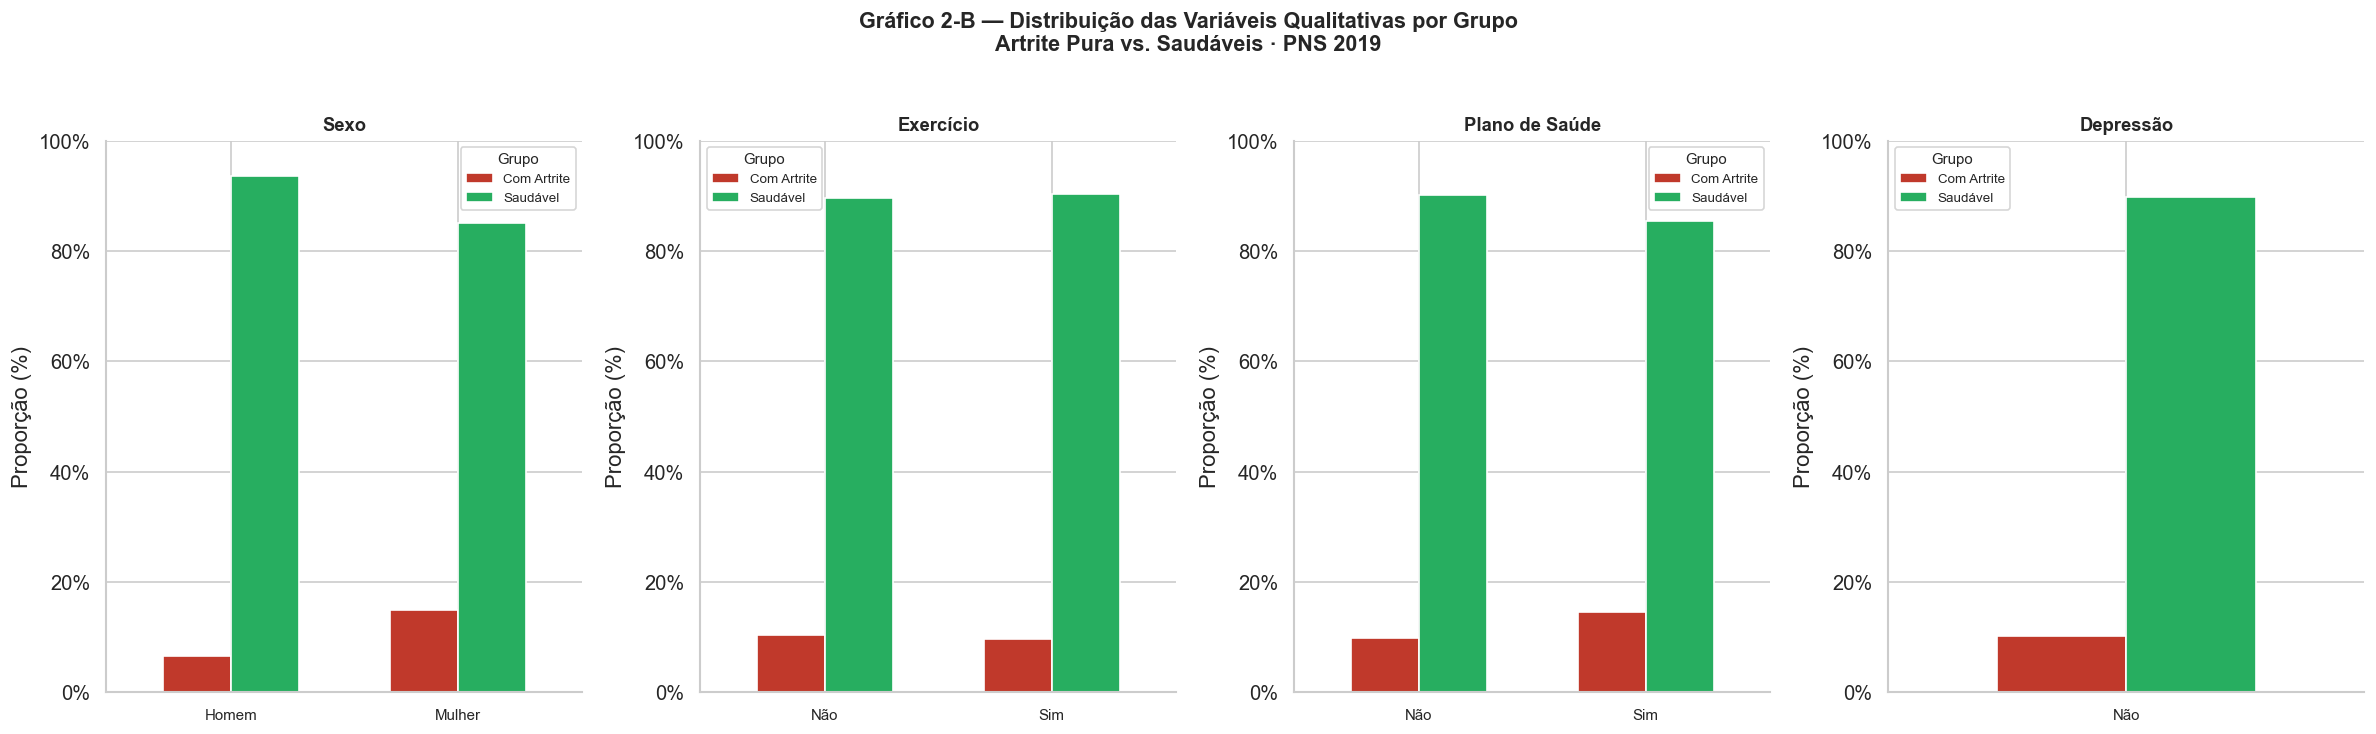

In [17]:
# ── Gráfico 2-B: barras agrupadas com eixo Y correto em % ────────────────
# BUG 4 CORRIGIDO: multiplicado por 100 + PercentFormatter + ylim(0,100)
# BUG 5 CORRIGIDO: sum(axis=1) em vez do sum(1) depreciado
VARS_BAR = {'C006':'Sexo', 'P034':'Exercício', 'I00101':'Plano de Saúde', 'Q092':'Depressão'}
MAP_BAR  = {'C006':MAP_SEXO, 'P034':MAP_SN, 'I00101':MAP_SN, 'Q092':MAP_SN}

fig, axes = plt.subplots(1, len(VARS_BAR), figsize=(5*len(VARS_BAR), 6))

for ax, (col, label) in zip(axes, VARS_BAR.items()):
    df_tmp      = df_biv[['Classe', col]].copy()
    df_tmp[col] = (df_tmp[col].astype(str).str.strip()
                              .map(MAP_BAR.get(col, {})).fillna(df_tmp[col]))
    tabela     = pd.crosstab(df_tmp[col], df_tmp['Classe'])
    # BUG 4+5 CORRIGIDO: axis=1 e * 100
    tabela_pct = tabela.div(tabela.sum(axis=1), axis=0) * 100

    tabela_pct.plot(kind='bar', ax=ax,
                   color=[COR_ARTRITE, COR_SAUDAVEL],
                   width=0.6, edgecolor='white', rot=0)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Proporção (%)')
    ax.set_ylim(0, 100)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
    ax.legend(title='Grupo', fontsize=8, title_fontsize=9)
    ax.tick_params(axis='x', labelsize=9)

fig.suptitle('Gráfico 2-B — Distribuição das Variáveis Qualitativas por Grupo\n'
             'Artrite Pura vs. Saudáveis · PNS 2019',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
salvar_fig('grafico_2B_barras_qualitativas.png')
plt.show()

---
## 2.3 · Bivariada — Artrite Pura vs. Saudáveis
**Produto:** Tabela 2-C

> **Bug 7 corrigido:** bivariada agora inclui todas as variáveis alimentares e de sedentarismo.

In [18]:
g_art = df_biv[df_biv['Classe']=='Com Artrite']
g_sau = df_biv[df_biv['Classe']=='Saudável']
linhas2c = []

# ── Variáveis Quantitativas: Mann-Whitney ou Teste t ─────────────────────
for col, rotulo in VARS_QUANT.items():
    s1 = g_art[col].dropna()
    s2 = g_sau[col].dropna()
    if len(s1) < 5 or len(s2) < 5: continue

    _, pn1 = stats.shapiro(s1.sample(min(len(s1),5000), random_state=RANDOM_STATE))
    _, pn2 = stats.shapiro(s2.sample(min(len(s2),5000), random_state=RANDOM_STATE))
    normal = (pn1 > ALPHA) and (pn2 > ALPHA)

    if normal:
        sv, p_val = stats.ttest_ind(s1, s2)
        teste = 'Teste t'
        stat_s = f't={sv:.3f}'
    else:
        sv, p_val = stats.mannwhitneyu(s1, s2, alternative='two-sided')
        teste = 'Mann-Whitney U'
        stat_s = f'U={sv:.0f}'

    # IC 95% da diferença de medianas (bootstrap 500 amostras)
    np.random.seed(RANDOM_STATE)
    diffs = [s1.sample(len(s1), replace=True).median() -
             s2.sample(len(s2), replace=True).median() for _ in range(500)]
    ic_i, ic_s = np.percentile(diffs, [2.5, 97.5])

    linhas2c.append({
        'Variável'         : rotulo,
        'Tipo'             : 'Quantitativa',
        'Artrite Med(IQR)' : f'{s1.median():.1f} ({s1.quantile(.25):.1f}–{s1.quantile(.75):.1f})',
        'Saudável Med(IQR)': f'{s2.median():.1f} ({s2.quantile(.25):.1f}–{s2.quantile(.75):.1f})',
        'Teste'            : teste,
        'Estatística'      : stat_s,
        'p-valor'          : f'{p_val:.4e}',
        'IC95% dif.med.'   : f'[{ic_i:.2f}; {ic_s:.2f}]',
        'Sig. α=5%'        : sig(p_val),
    })

# ── Variáveis Qualitativas: Qui-Quadrado ou Fisher ────────────────────────
for col, (rotulo, mapa) in VARS_QUAL.items():
    serie = df_biv[col].astype(str).str.strip()
    if mapa: serie = serie.map(mapa).fillna(serie)
    tab_ct = pd.crosstab(serie, df_biv['Classe'])
    if tab_ct.empty or tab_ct.shape[0] < 2: continue

    if tab_ct.values.min() < 5 and tab_ct.shape == (2,2):
        odds, p_val = stats.fisher_exact(tab_ct.values)
        teste = 'Fisher Exato'
        stat_s = f'OR={odds:.3f}'
    else:
        chi2, p_val, dof, _ = stats.chi2_contingency(tab_ct)
        teste = 'Qui-Quadrado'
        stat_s = f'χ²={chi2:.3f}'

    mod1 = serie[df_biv['Classe']=='Com Artrite'].mode().iloc[0]
    mod2 = serie[df_biv['Classe']=='Saudável'].mode().iloc[0]
    linhas2c.append({
        'Variável'         : rotulo,
        'Tipo'             : 'Qualitativa',
        'Artrite Med(IQR)' : f'Moda: {mod1}',
        'Saudável Med(IQR)': f'Moda: {mod2}',
        'Teste'            : teste,
        'Estatística'      : stat_s,
        'p-valor'          : f'{p_val:.4e}',
        'IC95% dif.med.'   : '—',
        'Sig. α=5%'        : sig(p_val),
    })

tab2c = pd.DataFrame(linhas2c)
print('='*110)
print('  TABELA 2-C — Bivariada Completa: Artrite Pura vs. Saudáveis')
print('  *** p<0,001  ** p<0,01  * p<0,05  ns = não significativo')
print('='*110)
print(tab2c.to_string(index=False))
salvar_tab(tab2c, 'tabela_2C_bivariada_completa.csv')

  TABELA 2-C — Bivariada Completa: Artrite Pura vs. Saudáveis
  *** p<0,001  ** p<0,01  * p<0,05  ns = não significativo
                    Variável         Tipo                            Artrite Med(IQR)                           Saudável Med(IQR)          Teste Estatística    p-valor IC95% dif.med. Sig. α=5%
                Idade (anos) Quantitativa                            67.0 (63.0–75.0)                            67.0 (63.0–73.0) Mann-Whitney U   U=1125555 5.7926e-02  [-1.00; 1.50]        ns
                 IMC (kg/m²) Quantitativa                            25.3 (22.8–28.4)                            24.8 (22.5–27.5) Mann-Whitney U   U=1149886 6.1311e-03   [0.06; 0.86]        **
       Exercício (dias/sem.) Quantitativa                               3.0 (2.0–5.0)                               3.0 (2.0–5.0) Mann-Whitney U     U=74618 1.2910e-01  [-1.00; 0.00]        ns
          Frutas (dias/sem.) Quantitativa                               6.0 (3.0–7.0)                      

---
## 2.4 · Correlação entre Preditoras
**Produtos:** Gráfico 2-D · Tabela 2-D

> **Bug 3 corrigido:** heatmap agora tem dados reais porque as colunas alimentares  
> são carregadas desde a Célula 1.

  Registros com dados completos para correlação: 0
  ✅ Figura → ../data/results/eda/figuras/grafico_2D_heatmap_correlacoes.png


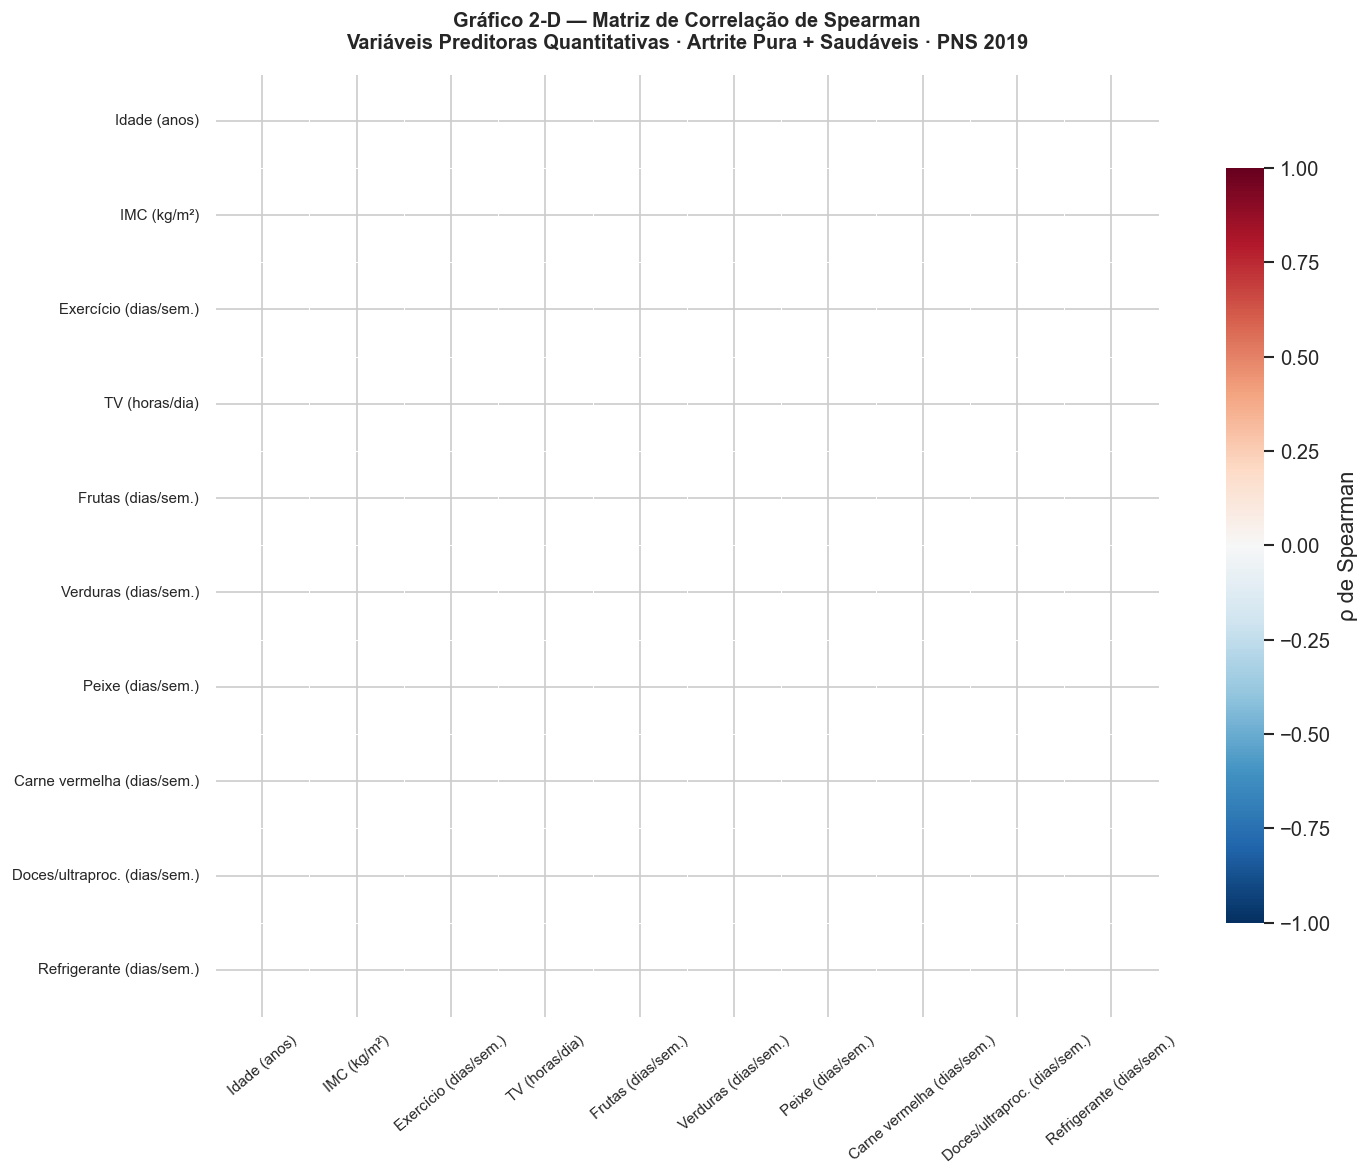

KeyError: 'ρ Spearman'

In [19]:
# BUG 3 CORRIGIDO: colunas antes ausentes (P035, P018...) agora existem em df_biv
cols_corr = list(VARS_QUANT.keys())
labs_corr  = list(VARS_QUANT.values())

df_corr  = df_biv[cols_corr].apply(pd.to_numeric, errors='coerce').dropna()
print(f'  Registros com dados completos para correlação: {len(df_corr):,}')
corr_mat = df_corr.corr(method='spearman')
corr_mat.columns = labs_corr
corr_mat.index   = labs_corr

mask = np.triu(np.ones_like(corr_mat, dtype=bool), k=1)
fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(corr_mat, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor='white', ax=ax, square=True,
            cbar_kws={'label': 'ρ de Spearman', 'shrink': 0.8})
ax.set_title('Gráfico 2-D — Matriz de Correlação de Spearman\n'
             'Variáveis Preditoras Quantitativas · Artrite Pura + Saudáveis · PNS 2019',
             fontsize=12, fontweight='bold', pad=15)
ax.tick_params(axis='x', labelrotation=40, labelsize=9)
ax.tick_params(axis='y', labelrotation=0,  labelsize=9)
plt.tight_layout()
salvar_fig('grafico_2D_heatmap_correlacoes.png')
plt.show()

# Tabela 2-D: pares com |ρ| > 0,50
pares = []
for i in range(len(cols_corr)):
    for j in range(i+1, len(cols_corr)):
        r, p_r = stats.spearmanr(df_corr[cols_corr[i]], df_corr[cols_corr[j]])
        if abs(r) > 0.50:
            interp = ('Alta ⚠️' if abs(r)>0.70
                      else 'Moderada-Alta' if abs(r)>0.60 else 'Moderada')
            pares.append({'Variável 1':labs_corr[i], 'Variável 2':labs_corr[j],
                          'ρ Spearman':round(r,3), 'p-valor':f'{p_r:.4e}',
                          'Interpretação':interp})

tab2d = pd.DataFrame(pares).sort_values('ρ Spearman', key=abs, ascending=False)
print('\n' + '='*75)
print('  TABELA 2-D — Pares com |ρ| > 0,50 (⚠️  acima de 0,70 = multicolinearidade)')
print('='*75)
print(tab2d.to_string(index=False) if len(tab2d) > 0 else '  Nenhum par com |ρ| > 0,50.')
salvar_tab(tab2d, 'tabela_2D_correlacoes_relevantes.csv')

---
## ✅ Sumário Final — Produtos Gerados

In [ ]:
produtos = [
    ('Tabela 3-B', DIR_TABELAS+'tabela_3B_prevalencia_subgrupos.csv',    'Prevalência por subgrupo com IC 95%'),
    ('Tabela 3-A', DIR_TABELAS+'tabela_3A_comparacao_quatro_bases.csv',  'Kruskal-Wallis: comparação das 4 bases'),
    ('Tabela 2-A', DIR_TABELAS+'tabela_2A_univariada_quantitativas.csv', 'Características basais: quantitativas'),
    ('Tabela 2-B', DIR_TABELAS+'tabela_2B_univariada_qualitativas.csv',  'Características basais: qualitativas'),
    ('Tabela 2-C', DIR_TABELAS+'tabela_2C_bivariada_completa.csv',       'Bivariada completa com p-valores e IC 95%'),
    ('Tabela 2-D', DIR_TABELAS+'tabela_2D_correlacoes_relevantes.csv',   'Pares de correlação com |ρ| > 0,50'),
    ('Gráfico 3-B', DIR_FIGURAS+'grafico_3B_prevalencia_subgrupos.png',  'Barras horizontais prevalência c/ IC 95%'),
    ('Gráfico 3-A', DIR_FIGURAS+'grafico_3A_boxplots_quatro_bases.png',  'Box plots comparativos das 4 bases'),
    ('Gráfico 2-A', DIR_FIGURAS+'grafico_2A_boxplots_quantitativas.png', 'Box plots quantitativas por grupo'),
    ('Gráfico 2-B', DIR_FIGURAS+'grafico_2B_barras_qualitativas.png',    'Barras agrupadas qualitativas'),
    ('Gráfico 2-D', DIR_FIGURAS+'grafico_2D_heatmap_correlacoes.png',    'Heatmap matriz de correlação de Spearman'),
]

print('='*85)
print('  ✅  PRODUTOS GERADOS — Fases 2 e 3 · PNS 2019')
print('  Filtro de integridade aplicado: V0015=1 (domicílio) + M001=1 (questionário)')
print('='*85)
for cod, path, desc in produtos:
    status = '✅' if os.path.exists(path) else '⚠️  NÃO GERADO'
    print(f'  {status}  {cod:12s}  {desc}')
print('='*85)
print('  Próximo: Notebook 03 — Regressão Logística e Modelagem ML (Fase 4)')